In [237]:
# https://platform.olimpiada-ai.ro/en/problems/94
# https://platform.olimpiada-ai.ro/en/problems/95

import os
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [238]:
train = pd.read_csv("/kaggle/input/datasets/abukanabek/analysis-churn-telecom/train.csv")
test = pd.read_csv("/kaggle/input/datasets/abukanabek/analysis-churn-telecom/test.csv")
subm = pd.read_csv("/kaggle/input/datasets/abukanabek/analysis-churn-telecom/sample_output.csv")

train.shape, test.shape, subm.shape

((5634, 54), (1409, 53), (4227, 3))

In [239]:
train.head()

,SampleID,Age,Avg Monthly GB Download,Avg Monthly Long Distance Charges,City,CLTV,Contract,Country,Customer ID,Dependents,...,Total Revenue,Under 30,Unlimited Data,Zip Code,Ping Score,Avg Speed,TV Type,Link Quality Index,Total Short Distance Charges,Churn
0,1,36,29,0.00,Snelling,4840,Month-to-Month,United States,6581-NQCBA,0,...,810.20,0,1,95369,73.483997,98.441872,Satellite Receiver,40.948442,22.976536,1
1,2,73,27,22.50,San Diego,3208,Month-to-Month,United States,8000-REIQB,0,...,102.45,0,0,92117,49.101754,99.903358,Internet,56.569219,-0.087549,1
2,3,60,13,1.27,Coarsegold,5355,One Year,United States,3442-ZHHCC,0,...,5109.36,0,1,93614,38.435240,99.877390,Satellite Receiver,63.179464,102.365883,0
3,4,54,21,0.00,Fairfax,5097,Month-to-Month,United States,2346-DJQTB,0,...,NaN,0,0,94930,42.155569,100.916879,Satellite Receiver,14.727121,55.686300,0
4,5,54,0,28.73,Myers Flat,2865,Month-to-Month,United States,4760-XOHVN,1,...,48.18,0,0,95554,51.993399,100.523227,Satellite Receiver,18.889887,5.972805,1


In [240]:
train['Churn'].value_counts(normalize=True)

Churn
0    0.734824
1    0.265176
Name: proportion, dtype: float64

In [241]:
pd.concat([pd.DataFrame(train.isna().sum()), pd.DataFrame(test.isna().sum())], axis=1)

,0,0
SampleID,0,0.0
Age,0,0.0
Avg Monthly GB Download,0,0.0
Avg Monthly Long Distance Charges,0,0.0
City,0,0.0
CLTV,0,0.0
Contract,0,0.0
Country,0,0.0
Customer ID,0,0.0
Dependents,0,0.0


In [242]:
train.select_dtypes('object')

,City,Contract,Country,Customer ID,Gender,Internet Type,Lat Long,Offer,Payment Method,Quarter,State,TV Type
0,Snelling,Month-to-Month,United States,6581-NQCBA,Female,DSL,"37.521708, -120.426843",Offer D,Bank Withdrawal,Q3,California,Satellite Receiver
1,San Diego,Month-to-Month,United States,8000-REIQB,Female,Fiber Optic,"32.825086, -117.199424",Offer E,Bank Withdrawal,Q3,California,Internet
2,Coarsegold,One Year,United States,3442-ZHHCC,Male,Cable,"37.212191, -119.749323",Offer A,Credit Card,Q3,California,Satellite Receiver
3,Fairfax,Month-to-Month,United States,2346-DJQTB,Female,DSL,"37.971751, -122.611873",NaN,Bank Withdrawal,Q3,California,Satellite Receiver
4,Myers Flat,Month-to-Month,United States,4760-XOHVN,Female,NaN,"40.267158, -123.805913",NaN,Mailed Check,Q3,California,Satellite Receiver
...,...,...,...,...,...,...,...,...,...,...,...,...
5629,Weaverville,Month-to-Month,United States,4183-WCSEP,Male,Fiber Optic,"40.759401, -122.939337",NaN,Bank Withdrawal,Q3,California,Cable
5630,Los Angeles,One Year,United States,9494-BDNNC,Male,Fiber Optic,"34.046174, -118.446333",NaN,Bank Withdrawal,Q3,California,Satellite Receiver
5631,Downey,Two Year,United States,1891-QRQSA,Male,Fiber Optic,"33.940884, -118.128628",Offer B,Bank Withdrawal,Q3,California,Cable
5632,El Sobrante,Month-to-Month,United States,1472-TNCWL,Male,Fiber Optic,"37.963995, -122.288296",NaN,Bank Withdrawal,Q3,California,Internet


In [243]:
def process(df):
    df['latitude'] = df['Lat Long'].map(lambda x: float(x.split(',')[0].strip()))
    df['longitude'] = df['Lat Long'].map(lambda x: float(x.split(',')[1].strip()))
    df.drop(columns=['Lat Long'], inplace=True)
    for c in df.select_dtypes('object').columns:
        df.loc[:, c].fillna('unknown', inplace=True)

process(train)
process(test)

/tmp/ipykernel_55/2870243183.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.loc[:, c].fillna('unknown', inplace=True)
/tmp/ipykernel_55/2870243183.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'd

In [244]:
from sklearn.model_selection import train_test_split

features = [c for c in train.columns if c not in ['SampleID', 'Customer ID', 'Churn']]
cat_features = [c for c in train.select_dtypes('object').columns if c in features]
target_col = 'Churn'

X, y = train[features], train[target_col]
X_test = test[features]

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.1, stratify=y, random_state=42)
X_train.shape, X_valid.shape

((5070, 52), (564, 52))

In [245]:
from catboost import CatBoostClassifier

params = {
    'iterations': 100,
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'metric_period': 10,
    'random_state': 42,
    'max_depth': 2
}

model = CatBoostClassifier(**params)

model.fit(X_train, y_train, eval_set=(X_valid, y_valid), cat_features=cat_features)

Learning rate set to 0.128839
0:	test: 0.9143156	best: 0.9143156 (0)	total: 5.27ms	remaining: 521ms
10:	test: 0.9869485	best: 0.9869485 (10)	total: 48.9ms	remaining: 396ms
20:	test: 0.9892029	best: 0.9892029 (20)	total: 90.9ms	remaining: 342ms
30:	test: 0.9898551	best: 0.9898551 (30)	total: 131ms	remaining: 292ms
40:	test: 0.9899436	best: 0.9899436 (40)	total: 173ms	remaining: 249ms
50:	test: 0.9903623	best: 0.9903623 (50)	total: 215ms	remaining: 207ms
60:	test: 0.9904911	best: 0.9904911 (60)	total: 256ms	remaining: 164ms
70:	test: 0.9905878	best: 0.9905878 (70)	total: 298ms	remaining: 122ms
80:	test: 0.9909420	best: 0.9909420 (80)	total: 341ms	remaining: 80ms
90:	test: 0.9907890	best: 0.9909420 (80)	total: 386ms	remaining: 38.2ms
99:	test: 0.9906602	best: 0.9909420 (80)	total: 425ms	remaining: 0us

bestTest = 0.990942029
bestIteration = 80

Shrink model to first 81 iterations.


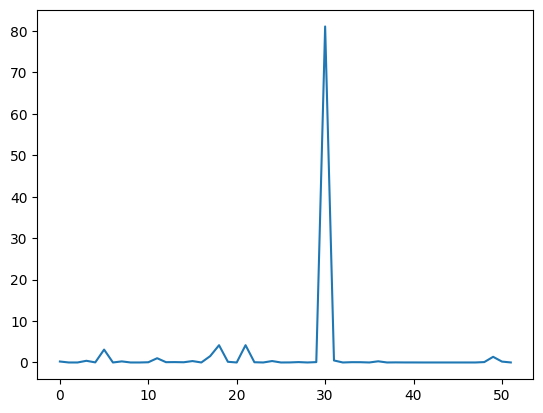

In [246]:
plt.plot(model.feature_importances_)
plt.show()

In [247]:
features[np.argmax(model.feature_importances_)]

'Satisfaction Score'

In [248]:
train.groupby('Satisfaction Score')['Churn'].mean()

Satisfaction Score
1    1.000000
2    1.000000
3    0.157746
4    0.000000
5    0.000000
Name: Churn, dtype: float64

In [249]:
y_pred = model.predict_proba(test[features])[:, 1].astype('float32')

subm['answer'] = (
    ((test['Monthly Charge'] > 70).astype(float) + (test['Total Extra Data Charges'] > 10).astype(float)).tolist() + 
    ((test['Avg Speed'] < 50).astype(float) + (test['Ping Score'] > 80).astype(float) + (test['Link Quality Index'] < 30).astype(float)).tolist() + 
    y_pred.tolist()
)

subm.to_csv("submission.csv", index=False)
subm.head()

,id,subtaskID,answer
0,5635,1,0.0
1,5636,1,1.0
2,5637,1,0.0
3,5638,1,1.0
4,5639,1,0.0
